In [31]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

In [32]:
import carregar_dados

In [33]:
dados_consolidados = carregar_dados.carregar_e_consolidar_dados()

#### Visualização

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [35]:
# Calcular as métricas para os gráficos
# Usar .agg() para calcular múltiplas métricas de uma vez

metricas = dados_consolidados.groupby('Loja').agg(
    Faturamento=('Preço', 'sum'),
    Avaliacao_Media=('Avaliação da compra', 'mean')
).reset_index()

print("Métricas calculadas para os gráficos:")
print(metricas)

Métricas calculadas para os gráficos:
     Loja  Faturamento  Avaliacao_Media
0  Loja 1   6138036.48         3.976685
1  Loja 2   5953836.24         4.037304
2  Loja 3   5856100.12         4.048326
3  Loja 4   5537990.32         3.995759


#### 1. Faturamento Mensal por Loja

In [43]:
# Converte a coluna de data para o formato datetime
dados_consolidados['Data da Compra'] = pd.to_datetime(dados_consolidados['Data da Compra'], format='%d/%m/%Y')

# Cria uma coluna 'Periodo' (Ano-Mês) para agrupar os dados
dados_consolidados['Periodo'] = dados_consolidados['Data da Compra'].dt.to_period('M')

# Agrupa os dados por Período e Loja, somando o Preço
faturamento_mensal = dados_consolidados.groupby(['Periodo', 'Loja'])['Preço'].sum().unstack()

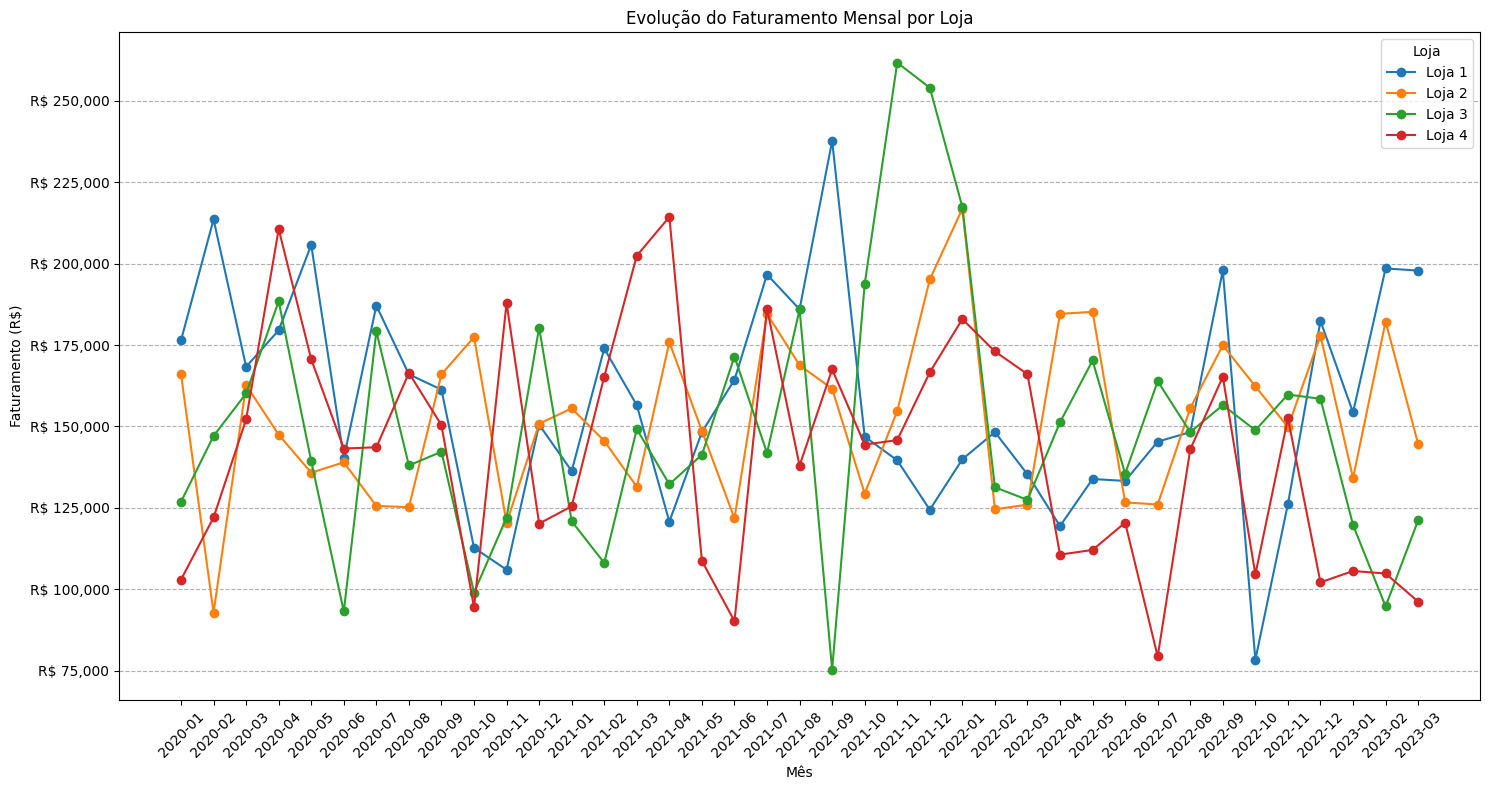

In [45]:
plt.figure(figsize=(15, 8))

# Plota uma linha para cada loja
for loja in faturamento_mensal.columns:
    plt.plot(faturamento_mensal.index.astype(str), faturamento_mensal[loja], marker='o', linestyle='-', label=loja)

plt.title('Evolução do Faturamento Mensal por Loja')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')

formatter = mticker.FuncFormatter(lambda x, p: f'R$ {x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(rotation=45)
plt.legend(title='Loja')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('../relatorios/faturamento_mensal_por_loja.png')
plt.show()

#### 2. Relação entre Preço e Frete

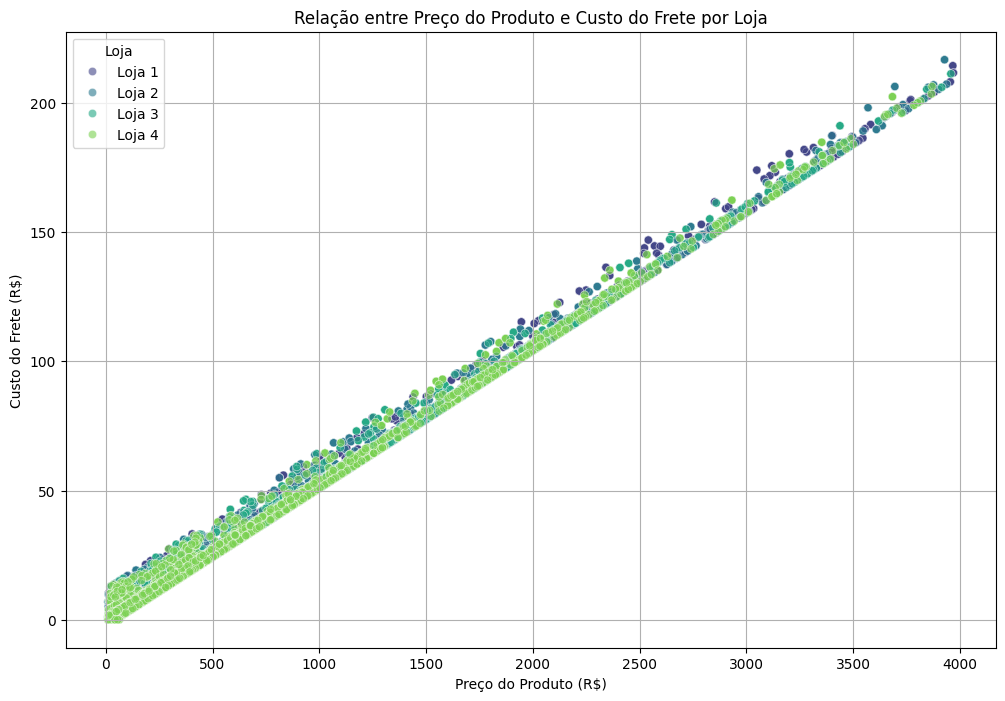

In [37]:
plt.figure(figsize=(12, 8))

# Usando a biblioteca seaborn para criar um gráfico de dispersão colorido por loja

sns.scatterplot(
    data=dados_consolidados, 
    x='Preço', 
    y='Frete', 
    hue='Loja',     
    alpha=0.6,      
    palette='viridis' 
)

plt.title('Relação entre Preço do Produto e Custo do Frete por Loja')
plt.xlabel('Preço do Produto (R$)')
plt.ylabel('Custo do Frete (R$)')
plt.grid(True) 

plt.savefig('../relatorios/preco_vs_frete.png')
plt.show()

#### 3. Distribuição de Categorias na Loja de Pior Desempenho

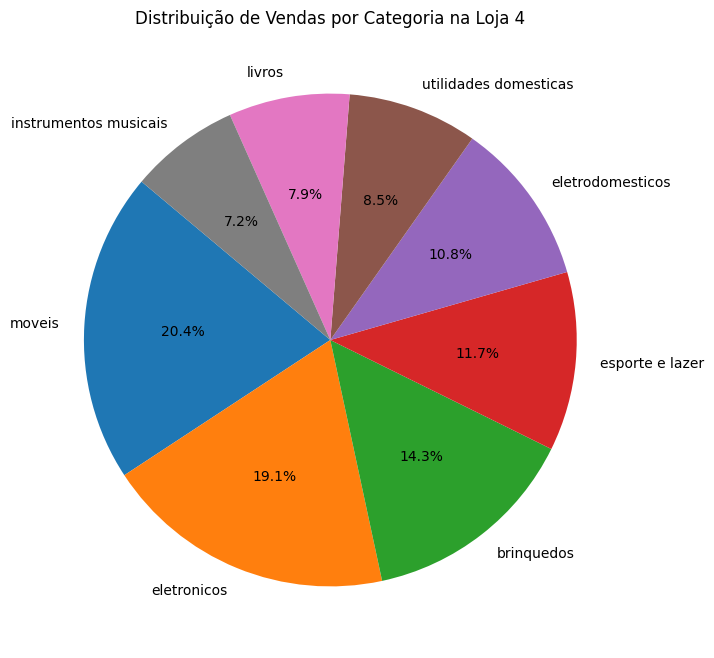

In [46]:
# Identifica a loja com o menor faturamento
loja_pior_faturamento = faturamento_sorted['Loja'].iloc[0] # type: ignore

plt.figure(figsize=(12, 8))
categorias_pior_loja = dados_consolidados[dados_consolidados['Loja'] == loja_pior_faturamento]['Categoria do Produto'].value_counts()

# Agrupa categorias com menos de 4% em "Outros" para um gráfico mais limpo
threshold = 0.04
small_categories = categorias_pior_loja[categorias_pior_loja / categorias_pior_loja.sum() < threshold]
if not small_categories.empty:
    others_sum = small_categories.sum()
    categorias_pior_loja = categorias_pior_loja[categorias_pior_loja / categorias_pior_loja.sum() >= threshold]
    categorias_pior_loja['Outros'] = others_sum

plt.pie(categorias_pior_loja, labels=categorias_pior_loja.index, autopct='%1.1f%%', startangle=140)
plt.title(f'Distribuição de Vendas por Categoria na {loja_pior_faturamento}')

# Remove o rótulo do eixo y que o gráfico de pizza adiciona
plt.ylabel('')

plt.savefig(f'../relatorios/categorias_{loja_pior_faturamento.replace(" ", "_").lower()}.png')
plt.show()